# Data Vis: Visualizing Numerical and Categorical Data
* Notebook 1: Visualizing Amounts

## Setup

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

## Data

In this notebook, we will use the NYC Flights 2013 dataset, which contains information about all domestic flights that departed from NYC in 2013. The dataset includes the following tables:
- `flights`: Contains information about each flight, including the origin and destination airports, departure and arrival times, and delays.
- `planes`: Contains information about the planes, including their tail numbers and model years.
- `airports`: Contains information about the airports, including their names and locations.
- `airlines`: Contains information about the airlines, including their names and IATA codes.
- `weather`: Contains information about the weather at the origin airports, including temperature, wind speed, and precipitation.

In [2]:
data = pd.read_csv('flights_joined.csv')

In [3]:
data.shape

(336776, 53)

In [4]:
data.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,tzone_dest,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,...,America/Chicago,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,...,America/Chicago,39.92,24.98,54.81,250.0,14.96014,21.86482,0.0,1011.4,10.0
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,...,America/New_York,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,...,NaN,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,...,America/New_York,39.92,24.98,54.81,260.0,16.11092,23.01560,0.0,1011.7,10.0


## Bar Chart

The bar chart is the most common way to visualize counts of categorical data. Here, we will use the figure-level function `catplot()` to create a bar chart of the number of flights by carrier. The `order`parameter is used to specify the order of the bars in the chart (here, by decreasing by counts).

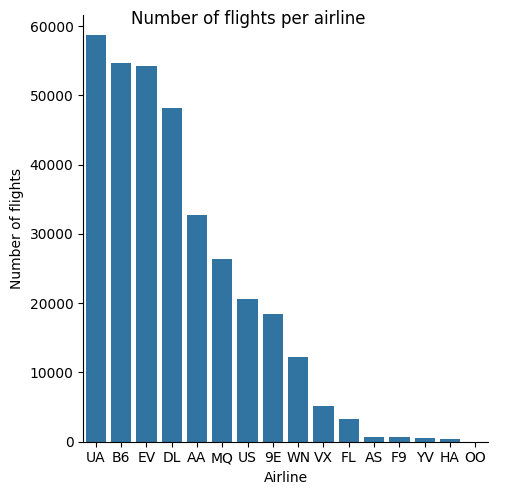

In [5]:
g = sns.catplot(x='carrier', data=data, kind='count', order=data['carrier'].value_counts().index)
g.fig.suptitle("Number of flights per airline")
g.set_xlabels("Airline")
g.set_ylabels("Number of flights")
plt.show()

We can create the same plot using the axes-level function `barplot()`, but we will need to use the `groupby()` method to aggregate the data first. So, the `catplot()` function is more convenient for this type of plot, as it automatically handles the aggregation for us.

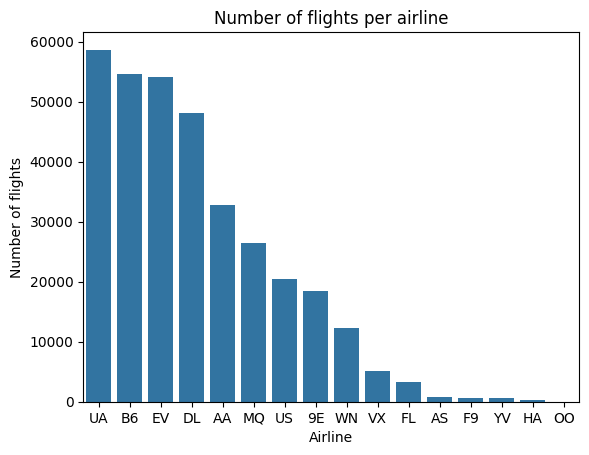

In [9]:
data_grouped = data.groupby('carrier').size().reset_index(name='count')
data_grouped = data_grouped.sort_values(by='count', ascending=False)

ax = sns.barplot(x='carrier', y='count', data=data_grouped)
ax.set_title("Number of flights per airline")
ax.set_xlabel("Airline")
ax.set_ylabel("Number of flights")
plt.show()

Next, we will create a stacked bar chart to show the number of flights by origin airport and airline carrier. We will use the `hue` parameter to specify the carrier, and the `multiple="stack"` parameter to stack the bars for each origin airport. 

In my opinion, it's a bit confusing that stacked bar charts are created using the `displot()` function, which is usually used for histograms.

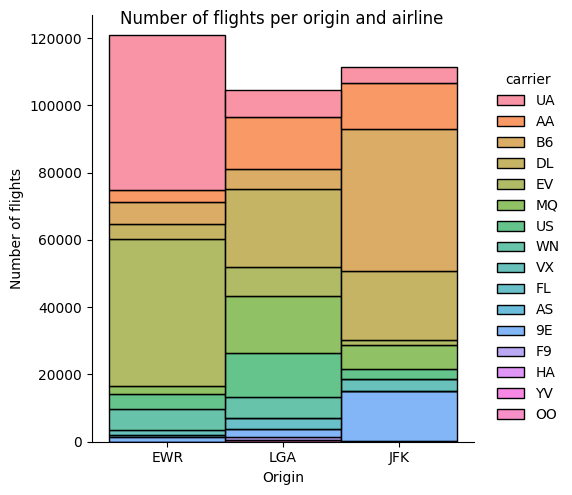

In [11]:
g = sns.displot(x="origin", hue="carrier", data=data, kind="hist", multiple="stack")
g.fig.suptitle("Number of flights per origin and airline")
g.set_xlabels("Origin")
g.set_ylabels("Number of flights")
plt.show()

Similarily, we can create a grouped bar chart to show the number of flights by origin airport and airline carrier, using the `multiple="stack"` parameter to group the bars for each origin airport.

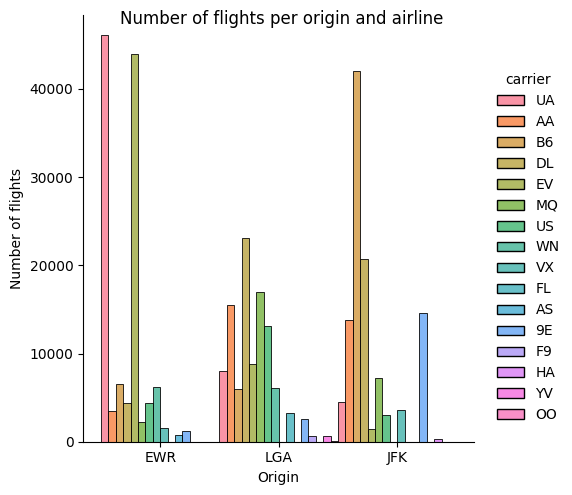

In [12]:
g = sns.displot(x="origin", hue="carrier", data=data, kind="hist", multiple="dodge")
g.fig.suptitle("Number of flights per origin and airline")
g.set_xlabels("Origin")
g.set_ylabels("Number of flights")
plt.show()

Now it's your turn. Create bar charts, stacked bar charts, and grouped bar charts to show the number of flights by other categorical variables in the dataset...

In [ ]:
# YOUR CODE HERE

## Heatmap

Heatmaps are another way to visualize counts of categorical data. They are particularly useful for visualizing the relationship between two categorical variables. In this example, we will create a heatmap to show the number of flights by `weekday` and `hour`.

The variable `weekday`does not exist in the dataset, so we will create it by extracting the day of the week from the `time_hour` variable.

In [13]:
data["weekday"] = pd.to_datetime(data["time_hour"]).dt.day_name()

In [14]:
data

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,weekday
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,...,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0,Tuesday
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,...,39.92,24.98,54.81,250.0,14.96014,21.86482,0.0,1011.4,10.0,Tuesday
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,...,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0,Tuesday
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,...,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0,Tuesday
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,...,39.92,24.98,54.81,260.0,16.11092,23.01560,0.0,1011.7,10.0,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,2013,9,30,NaN,1455,NaN,NaN,1634,NaN,9E,...,68.00,55.04,63.21,190.0,11.50780,NaN,0.0,1016.6,10.0,Monday
336772,2013,9,30,NaN,2200,NaN,NaN,2312,NaN,9E,...,64.94,53.06,65.37,200.0,6.90468,NaN,0.0,1015.8,10.0,Tuesday
336773,2013,9,30,NaN,1210,NaN,NaN,1330,NaN,MQ,...,69.08,48.02,46.99,70.0,5.75390,NaN,0.0,1016.7,10.0,Monday
336774,2013,9,30,NaN,1159,NaN,NaN,1344,NaN,MQ,...,66.92,48.92,52.35,70.0,8.05546,NaN,0.0,1017.5,10.0,Monday


First, we have to aggregate the raw data by `weekday` and `hour` before we can create the heatmap. This can be done with the `pivot_table()` method, which creates a pivot table from the raw data. The `pivot_table()` method takes the following parameters:
- `index`: The variable to use for the rows of the pivot table (here, `hour`).
- `columns`: The variable to use for the columns of the pivot table (here, `weekday`).
- `values`: The variable to use for the values of the pivot table (here, `flight`).
- `aggfunc`: The aggregation function to use for the values of the pivot table (here, `count`).

In [15]:
pivot_table = data.pivot_table(index="hour", columns="weekday", values="flight", aggfunc="count")
pivot_table.head(10)

weekday,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
hour,,,,,,,
1,NaN,NaN,1.0,NaN,NaN,NaN,NaN
5,288.0,293.0,277.0,221.0,293.0,297.0,284.0
6,4059.0,4130.0,3062.0,2464.0,4094.0,4107.0,4035.0
7,3437.0,3483.0,2675.0,2784.0,3468.0,3526.0,3448.0
8,4031.0,4074.0,3442.0,3477.0,4053.0,4120.0,4045.0
9,2951.0,3001.0,2598.0,2802.0,2991.0,3019.0,2950.0
10,2510.0,2518.0,1983.0,2195.0,2520.0,2499.0,2483.0
11,2367.0,2375.0,1986.0,2177.0,2377.0,2388.0,2363.0
12,2686.0,2726.0,2066.0,2623.0,2685.0,2713.0,2682.0


The weekdays are not ordered correctly, so we will use the `reindex()` method to get the columns in the right order.

In [16]:
ordered_weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot_table = pivot_table.reindex(columns=ordered_weekdays)
pivot_table.head(10)

weekday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
hour,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,1.0,NaN
5,293.0,297.0,284.0,293.0,288.0,277.0,221.0
6,4130.0,4107.0,4035.0,4094.0,4059.0,3062.0,2464.0
7,3483.0,3526.0,3448.0,3468.0,3437.0,2675.0,2784.0
8,4074.0,4120.0,4045.0,4053.0,4031.0,3442.0,3477.0
9,3001.0,3019.0,2950.0,2991.0,2951.0,2598.0,2802.0
10,2518.0,2499.0,2483.0,2520.0,2510.0,1983.0,2195.0
11,2375.0,2388.0,2363.0,2377.0,2367.0,1986.0,2177.0
12,2726.0,2713.0,2682.0,2685.0,2686.0,2066.0,2623.0


Note that there are `NaN` values in the pivot table. There are also missing rows for hours with no flights. Let's fix these issues.

In [17]:
for hour in range(24):
    if hour not in pivot_table.index:
        pivot_table.loc[hour] = 0
        
pivot_table = pivot_table.fillna(0)
pivot_table = pivot_table.sort_index()

pivot_table.head(10)

weekday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
hour,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,293.0,297.0,284.0,293.0,288.0,277.0,221.0
6,4130.0,4107.0,4035.0,4094.0,4059.0,3062.0,2464.0
7,3483.0,3526.0,3448.0,3468.0,3437.0,2675.0,2784.0
8,4074.0,4120.0,4045.0,4053.0,4031.0,3442.0,3477.0


Finally, we are reday to create the heatmap. We will use the `heatmap()` function to create the heatmap. The `cmap`, `linewidths`, and `linecolor` parameters, amongst others, can be used to customize the appearance of the heatmap. See https://seaborn.pydata.org/generated/seaborn.heatmap.html for more details.

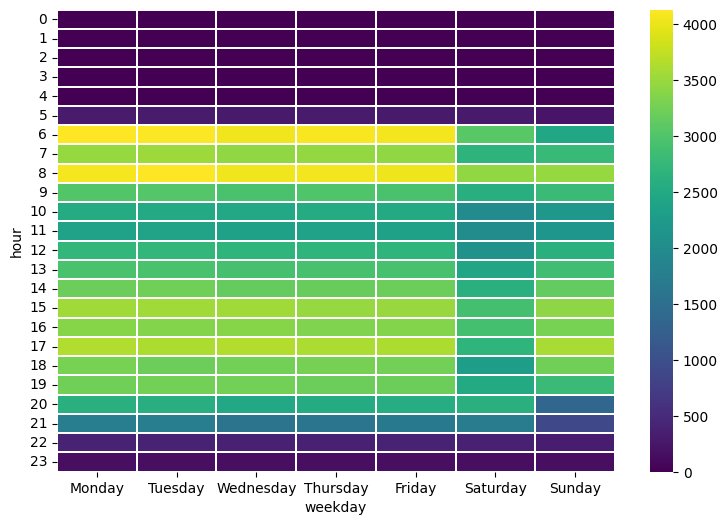

In [24]:
fig = plt.figure(figsize=(9, 6))
ax = sns.heatmap(data=pivot_table, cmap='viridis', linewidths=0.1, linecolor='white')
plt.yticks(rotation=0)
plt.show()

Now it's your turn. Create a heatmap using other categorical variables in the dataset...

In [ ]:
# YOUR CODE HERE